# Results: Constrained Mean-Variance vs. Passive Equity Portfolios

**Author:** Valerian Meipariani &nbsp;|&nbsp; **Supervisor Review Draft** &nbsp;|&nbsp; **Date:** May 2026

---

This notebook presents the empirical findings of the thesis, organised by
hypothesis.  It feeds directly into the Results (Section 5) and Discussion
(Section 6) chapters of the written submission.

Coverage: regime classification and sample-period motivation (§1), descriptive
risk-return performance across the full period and the post-2015 high-coverage
subsample (§2), the Jobson-Korkie-Memmel Sharpe ratio test for H1 (§3), the
factor regression analysis (§4), the regime-conditional bootstrap for H2 (§5),
and a synthesised conclusion across both hypotheses (§6).

**All outputs are reproducible from cached files in `data/processed/` and
`results/`.  No data is re-downloaded and no backtests are re-run.**


In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT / "code") not in sys.path:
    sys.path.insert(0, str(ROOT / "code"))

FIGURES = ROOT / "outputs" / "figures"
TABLES  = ROOT / "outputs" / "tables"
DATA    = ROOT / "data"   / "processed"

# ── Thesis palette ─────────────────────────────────────────────────────────────
_NAVY = "#1f3a68"   # MV gross
_GREY = "#888888"   # MV net
_RED  = "#c0392b"   # benchmark
_TEAL = "#2c7873"   # 1/N

import matplotlib
matplotlib.rcParams.update({
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e0e0e0",
    "grid.linewidth":    0.6,
    "axes.axisbelow":    True,
    "font.family":       "DejaVu Sans",
})
warnings.filterwarnings("ignore")

# ── Helper: format a metrics DataFrame for display ─────────────────────────────
_STRAT_LABELS = {
    "mv_gross": "MV gross",
    "mv_net":   "MV net",
    "naive":    "1/N equal-weight",
    "benchmark":"S&P 500 TR",
}

def fmt_metrics(df):
    out = df.copy()
    out["strategy"]       = out["strategy"].map(_STRAT_LABELS).fillna(out["strategy"])
    out["total_return"]   = out["total_return"].map("{:+.1%}".format)
    out["ann_return"]     = out["ann_return"].map("{:+.2%}".format)
    out["ann_volatility"] = out["ann_volatility"].map("{:.2%}".format)
    out["sharpe"]         = out["sharpe"].map("{:.3f}".format)
    out["sortino"]        = out["sortino"].map("{:.3f}".format)
    out["max_drawdown"]   = out["max_drawdown"].map("{:+.1%}".format)
    out = out.drop(columns=["n_months"], errors="ignore")
    out.columns = ["Strategy", "Total Return", "Ann. Return",
                   "Ann. Vol", "Sharpe", "Sortino", "Max DD"]
    return out

print(f"FIGURES : {FIGURES}")
print(f"TABLES  : {TABLES}")


FIGURES : C:\Users\vakom\OneDrive\Desktop\MA Thesis\outputs\figures
TABLES  : C:\Users\vakom\OneDrive\Desktop\MA Thesis\outputs\tables


---
## 1. Sample Periods and Regime Classification


### 1a. Two evaluation windows: motivation

The analysis reports results across two nested subsamples, reflecting an
asymmetry in data quality that is material for interpreting the findings.

The **full evaluation window (2001-02 to 2024-12, 287 months)** is the primary
sample.  It encompasses three complete bear-market cycles and provides the
longest available history for assessing H1 and H2.  However, price-data
coverage for S&P 500 members rises monotonically from approximately 51% in
early 2001 to 97% by 2024, as Yahoo Finance's archive for delisted and acquired
firms thins out in the early years.  Strategies that operate on an incomplete
universe — as both the MV and 1/N portfolios do — are systematically excluding
non-surviving firms, biasing their measured returns upward relative to the
total-return benchmark, which tracks all members including eventual failures.

The **post-2015 subsample (2015-01 to 2024-12, 120 months)** is the primary
robustness check: coverage averages 86.9% (minimum 73.7%) over this window,
the survivorship gap is substantially narrower, and any residual outperformance
is more likely to reflect genuine strategy performance than a data-quality
artefact.  If risk-adjusted results hold in the post-2015 window, they survive
the most important data-quality challenge facing the study.  All key tables are
reported for both windows side-by-side.


Regime classification — main definition (>= -20% drawdown threshold)


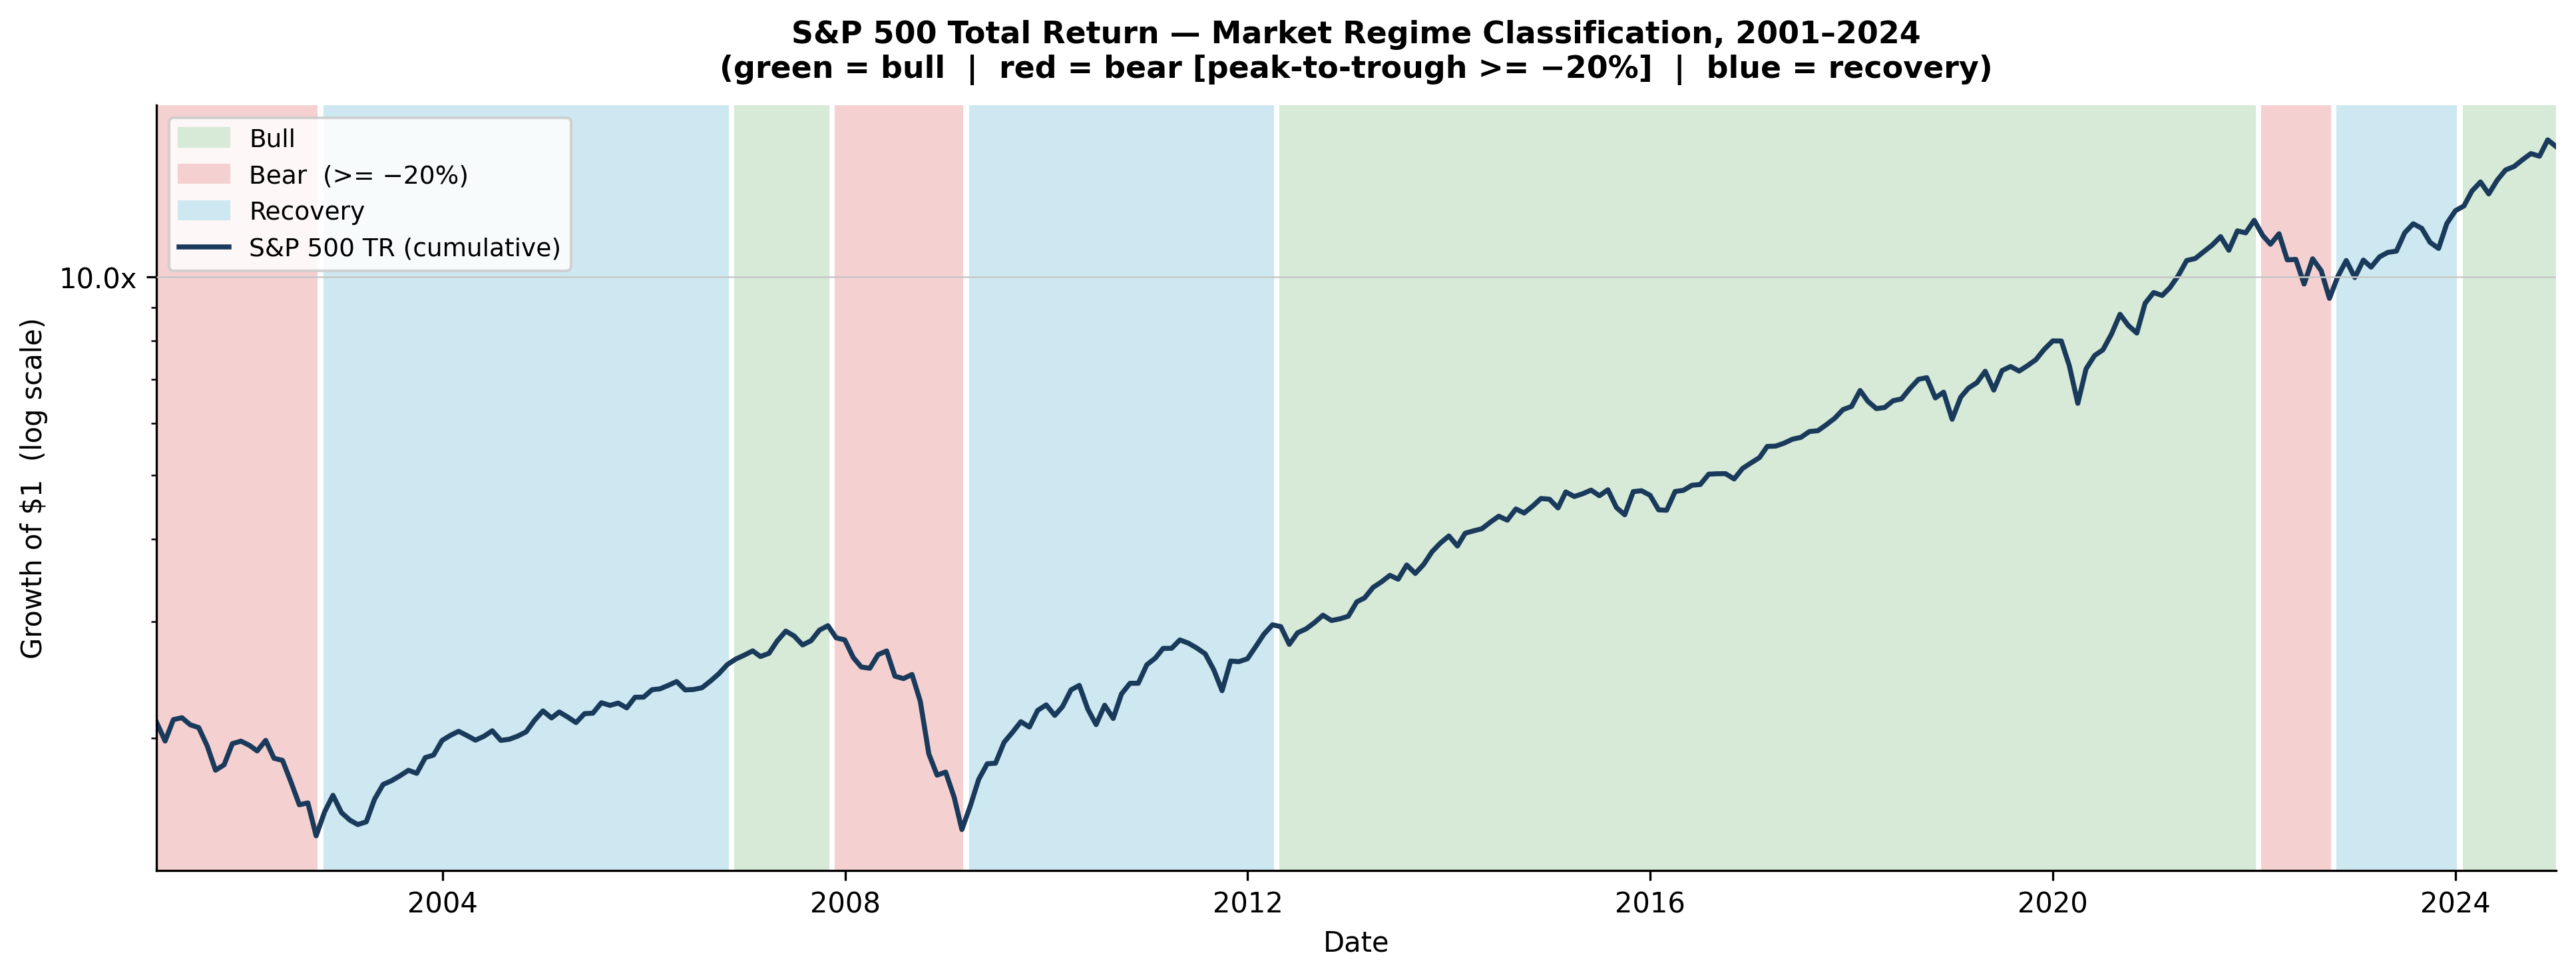


Regime classification — sensitivity version (>= -15% drawdown threshold)


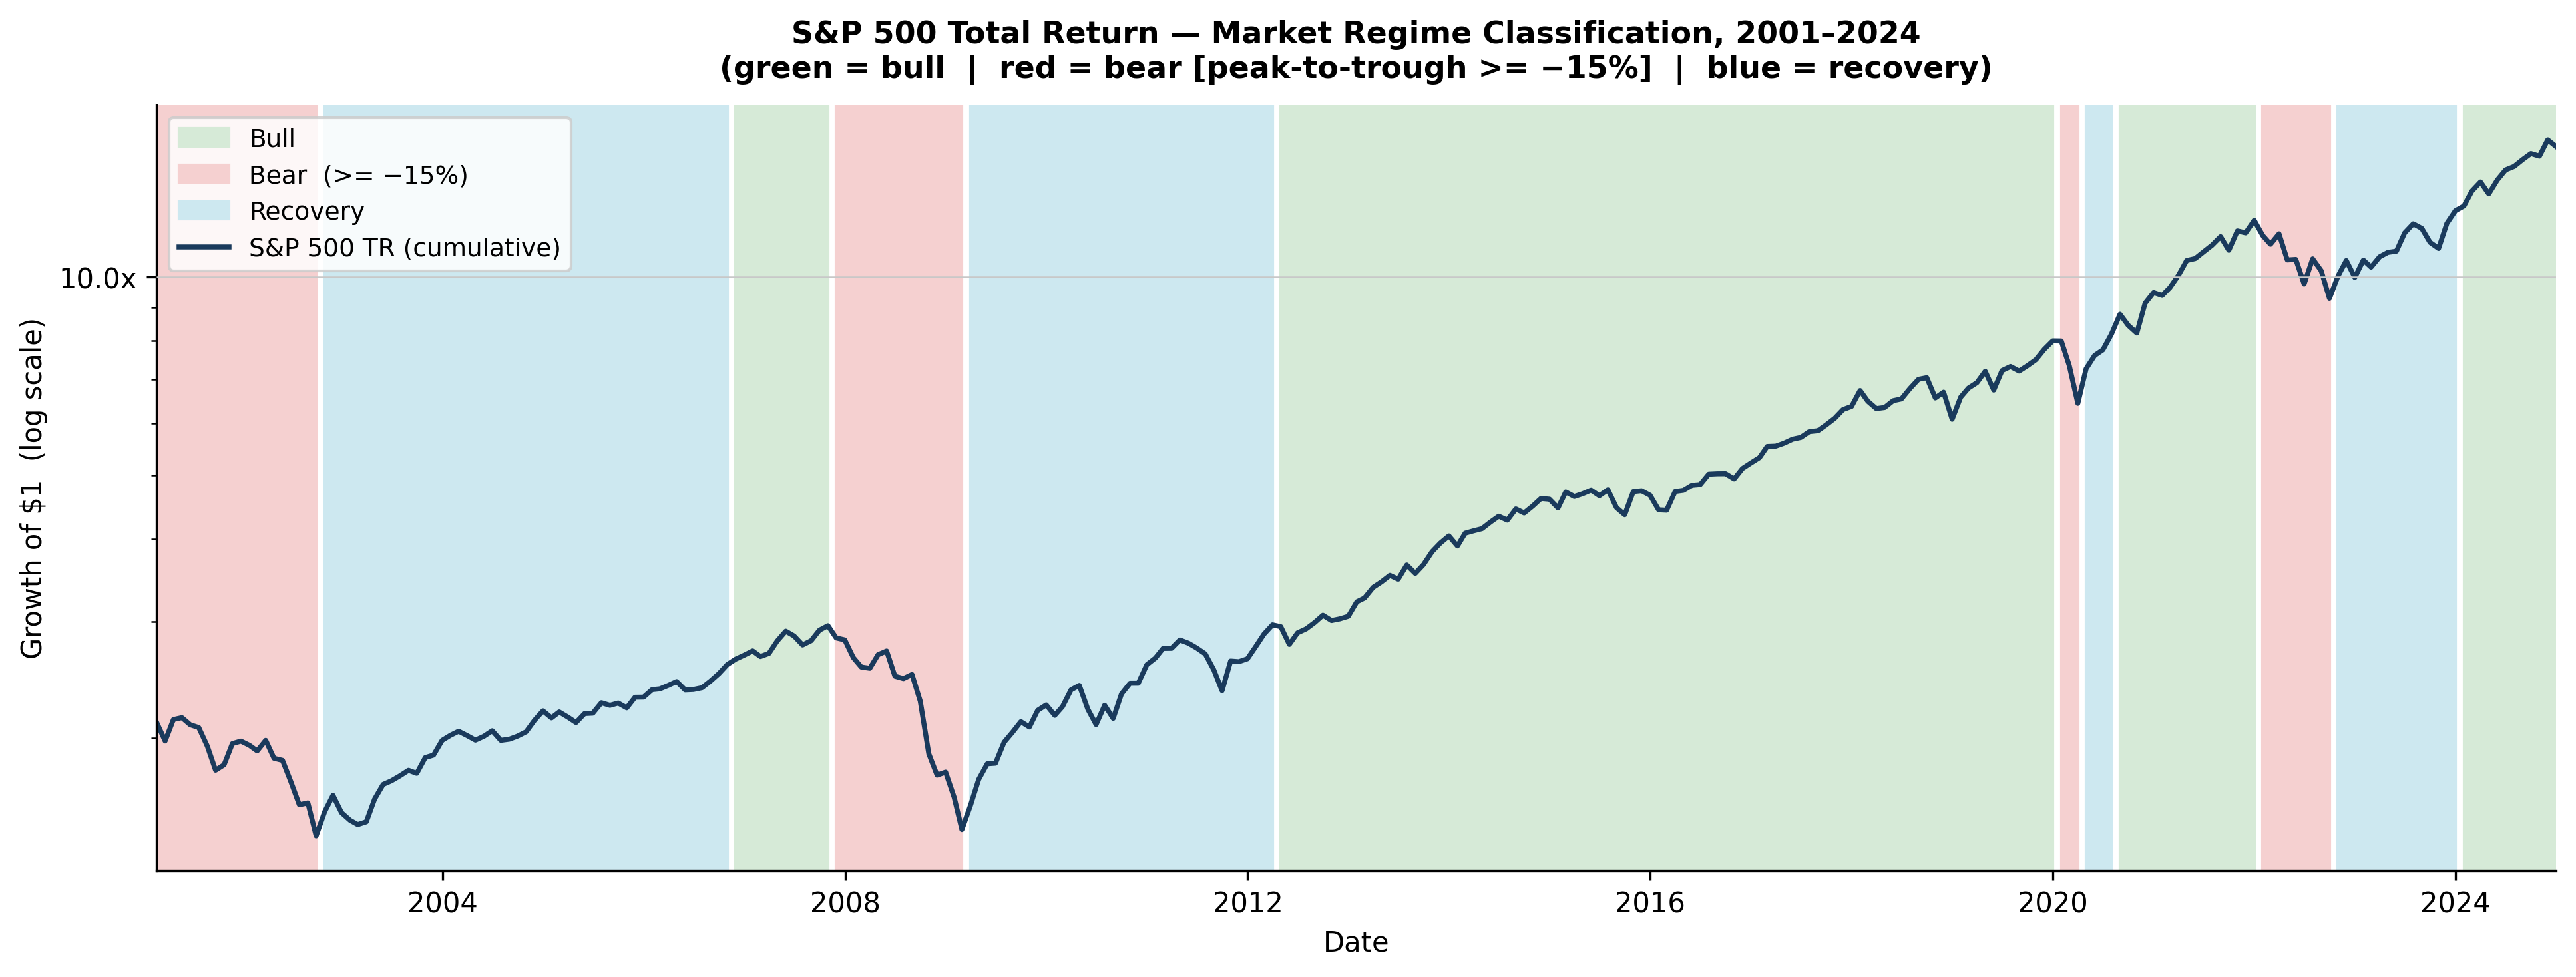

In [2]:
print("Regime classification — main definition (>= -20% drawdown threshold)")
display(Image(filename=str(FIGURES / "regimes_timeline_main.png"), width=950))
print()
print("Regime classification — sensitivity version (>= -15% drawdown threshold)")
display(Image(filename=str(FIGURES / "regimes_timeline_sensitivity.png"), width=950))


The two figures illustrate the main (−20%) and sensitivity (−15%) regime
classifications over the evaluation window.  The main definition identifies
three bear-market episodes — dot-com bust (2001-02 to 2002-09, 20 months),
Global Financial Crisis (2007-11 to 2009-02, 16 months), and the 2022
rate-shock bear (2022-01 to 2022-09, 9 months) — totalling 45 bear months
(15.7% of the sample) and 101 recovery months (35.2%).  The sensitivity
definition adds a fourth episode for the COVID-19 crash (2020-01 to 2020-03,
3 months), discussed below.

The consequence for the bear-regime analysis is that the main classification
concentrates all three bear episodes in the full period, with only 9 bear months
falling in the post-2015 subsample (the 2022 episode only).  The sensitivity
classification adds 3 COVID bear months and 4 recovery months post-2015,
providing a small but meaningful additional data point on strategy behaviour
during acute market stress.


### 1b. Regime episode tables and the COVID detection issue

**Why the −20% threshold misses the COVID crash.**  The SARS-CoV-2 pandemic
triggered the fastest bear market on record in daily terms: from the
S&P 500 TR all-time high on 19 January 2020 to the intraday trough on
23 March 2020, the index fell approximately −34%.  However, the regime
algorithm in this study operates on **month-end closing prices**.  The January
2020 close was the all-time high; the February 2020 close was approximately
−8.3% below that peak; the March 2020 close was approximately −19.8% below
the January peak — just 0.2 percentage points short of the −20% confirmation
threshold.  The flash-crash and recovery occurred almost entirely within one
calendar month, leaving no −20% monthly close signal.

This is a known limitation of monthly-frequency drawdown detection, not an
error.  The choice of monthly data is deliberate (the optimisation window and
rebalance frequency are both monthly), and adjusting the threshold retroactively
to capture a single episode would be an arbitrary *ex post* modification.
Instead, a **−15% sensitivity threshold** is reported alongside the main
results.  At −15%, the March 2020 close (−19.8% from the January peak) exceeds
the trigger, and the COVID episode is classified as a 3-month bear (2020-01 to
2020-03) followed by a 4-month recovery (2020-04 to 2020-07).  The robustness
of findings across both thresholds is reported explicitly in §5.


In [3]:
eps_main = pd.read_csv(TABLES / "regime_episodes_main.csv", parse_dates=["start_date","end_date"])
eps_sens = pd.read_csv(TABLES / "regime_episodes_sensitivity.csv", parse_dates=["start_date","end_date"])

def fmt_episodes(df):
    out = df.copy()
    out["start_date"] = out["start_date"].dt.strftime("%Y-%m")
    out["end_date"]   = out["end_date"].dt.strftime("%Y-%m")
    out.columns       = ["Regime", "Start", "End", "Months"]
    return out

print("Episode table — main definition (>= -20%)")
display(fmt_episodes(eps_main).style.set_properties(
    **{"text-align": "left"}).hide(axis="index"))

print()
print("Episode table — sensitivity definition (>= -15%)")
display(fmt_episodes(eps_sens).style.set_properties(
    **{"text-align": "left"}).hide(axis="index"))

print()
counts_main = eps_main.groupby("regime")["n_months"].sum()
counts_sens = eps_sens.groupby("regime")["n_months"].sum()
cmp = pd.DataFrame({"Main (-20%)": counts_main, "Sensitivity (-15%)": counts_sens,
                    "Delta": counts_sens - counts_main}).loc[["bull","bear","recovery"]]
cmp.index.name = "Regime"
print("Month-count comparison:")
display(cmp)


Episode table — main definition (>= -20%)


Regime,Start,End,Months
bear,2001-02,2002-09,20
recovery,2002-10,2006-10,49
bull,2006-11,2007-10,12
bear,2007-11,2009-02,16
recovery,2009-03,2012-03,37
bull,2012-04,2021-12,117
bear,2022-01,2022-09,9
recovery,2022-10,2023-12,15
bull,2024-01,2024-12,12



Episode table — sensitivity definition (>= -15%)


Regime,Start,End,Months
bear,2001-02,2002-09,20
recovery,2002-10,2006-10,49
bull,2006-11,2007-10,12
bear,2007-11,2009-02,16
recovery,2009-03,2012-03,37
bull,2012-04,2019-12,93
bear,2020-01,2020-03,3
recovery,2020-04,2020-07,4
bull,2020-08,2021-12,17
bear,2022-01,2022-09,9



Month-count comparison:


,Main (-20%),Sensitivity (-15%),Delta
Regime,,,
bull,141,134,-7
bear,45,48,3
recovery,101,105,4


---
## 2. Descriptive Performance


### 2a. Risk-return metrics

The tables below report annualised return, annualised volatility, Sharpe ratio
(using the Kenneth French monthly risk-free rate, mean 1.58% p.a. over the
evaluation period), Sortino ratio (semi-deviation denominator), and maximum
drawdown, for each of the four series.  The full-period and post-2015 results
are presented side by side to allow direct assessment of how much the headline
numbers change as data quality improves.

The primary theoretical prediction of minimum-variance optimisation is
**volatility reduction relative to the cap-weighted benchmark** — not raw-return
maximisation.  The correct metric for H1 is the Sharpe ratio, but the volatility
and drawdown columns provide the necessary context: if the strategy fails to
reduce volatility, the optimisation is not functioning as designed.


In [4]:
mfp = pd.read_csv(TABLES / "metrics_full_period.csv")
mp5 = pd.read_csv(TABLES / "metrics_post_2015.csv")

print("Full period  (2001-02 to 2024-12,  n = 287 months)")
display(fmt_metrics(mfp).style.set_properties(**{"text-align":"right"})
        .set_properties(subset=["Strategy"], **{"text-align":"left"}).hide(axis="index"))

print()
print("Post-2015 subsample  (2015-01 to 2024-12,  n = 120 months)")
display(fmt_metrics(mp5).style.set_properties(**{"text-align":"right"})
        .set_properties(subset=["Strategy"], **{"text-align":"left"}).hide(axis="index"))


Full period  (2001-02 to 2024-12,  n = 287 months)


Strategy,Total Return,Ann. Return,Ann. Vol,Sharpe,Sortino,Max DD
MV gross,+676.0%,+8.95%,11.64%,0.659,0.963,-42.1%
MV net,+630.3%,+8.67%,11.64%,0.637,0.927,-42.4%
1/N equal-weight,+981.0%,+10.47%,16.96%,0.580,0.869,-54.5%
S&P 500 TR,+578.7%,+8.34%,15.25%,0.499,0.724,-50.9%



Post-2015 subsample  (2015-01 to 2024-12,  n = 120 months)


Strategy,Total Return,Ann. Return,Ann. Vol,Sharpe,Sortino,Max DD
MV gross,+161.5%,+10.09%,12.43%,0.701,1.061,-17.1%
MV net,+154.5%,+9.79%,12.42%,0.679,1.023,-17.2%
1/N equal-weight,+185.8%,+11.07%,16.92%,0.608,0.933,-26.9%
S&P 500 TR,+242.5%,+13.10%,15.36%,0.774,1.211,-23.9%


**Volatility reduction is real and persistent across subsamples.**  Over the
full period, the constrained MV strategy achieves annualised volatility of
11.64%, compared to 15.25% for the `^SP500TR` benchmark — a ratio of 0.76.
In the post-2015 subsample, the corresponding figures are 12.43% and 15.36%
(ratio 0.81), confirming that variance reduction is not concentrated in the
high-coverage tail of the sample.  The maximum drawdown tells the same story:
−42.1% (MV gross) versus −50.9% (benchmark) over the full period, and −17.1%
versus −23.9% in the post-2015 window.  These are the strategy's most
defensible empirical results.

**The raw return picture is materially different in the two windows.**  Over
the full period, MV gross returns +8.95% p.a. against the benchmark's +8.34%,
a nominal premium of 61 basis points.  In the post-2015 window that premium
reverses: MV gross returns +10.09% p.a. against the benchmark's +13.10%,
a shortfall of approximately 300 basis points per year.  This reversal is
consistent with the survivorship-bias hypothesis: the early-period outperformance
(concentrated in the 51–73% coverage era) is partly attributable to the active
universe excluding the worst-performing historical members.  The Sharpe ratio
comparison in §3 tests whether any premium survives on a risk-adjusted basis.

**Equal-weighting underperforms the benchmark in the post-2015 window.**
The 1/N portfolio, which beats the benchmark by over 200 basis points per year
over the full period, falls short by approximately 200 basis points per year
post-2015 — a symmetric flip that confirms the coverage-artefact interpretation.
When the universe is nearly complete (2015–2024), departing the cap-weighted
benchmark via equal-weighting yields no systematic return advantage.


### 2b. Cumulative performance and drawdown profile

The cumulative return figure (log scale) and the running maximum drawdown plot
together communicate two distinct but complementary aspects of strategy
behaviour: wealth accumulation over the full cycle, and the cost of the worst
peak-to-trough declines along the way.


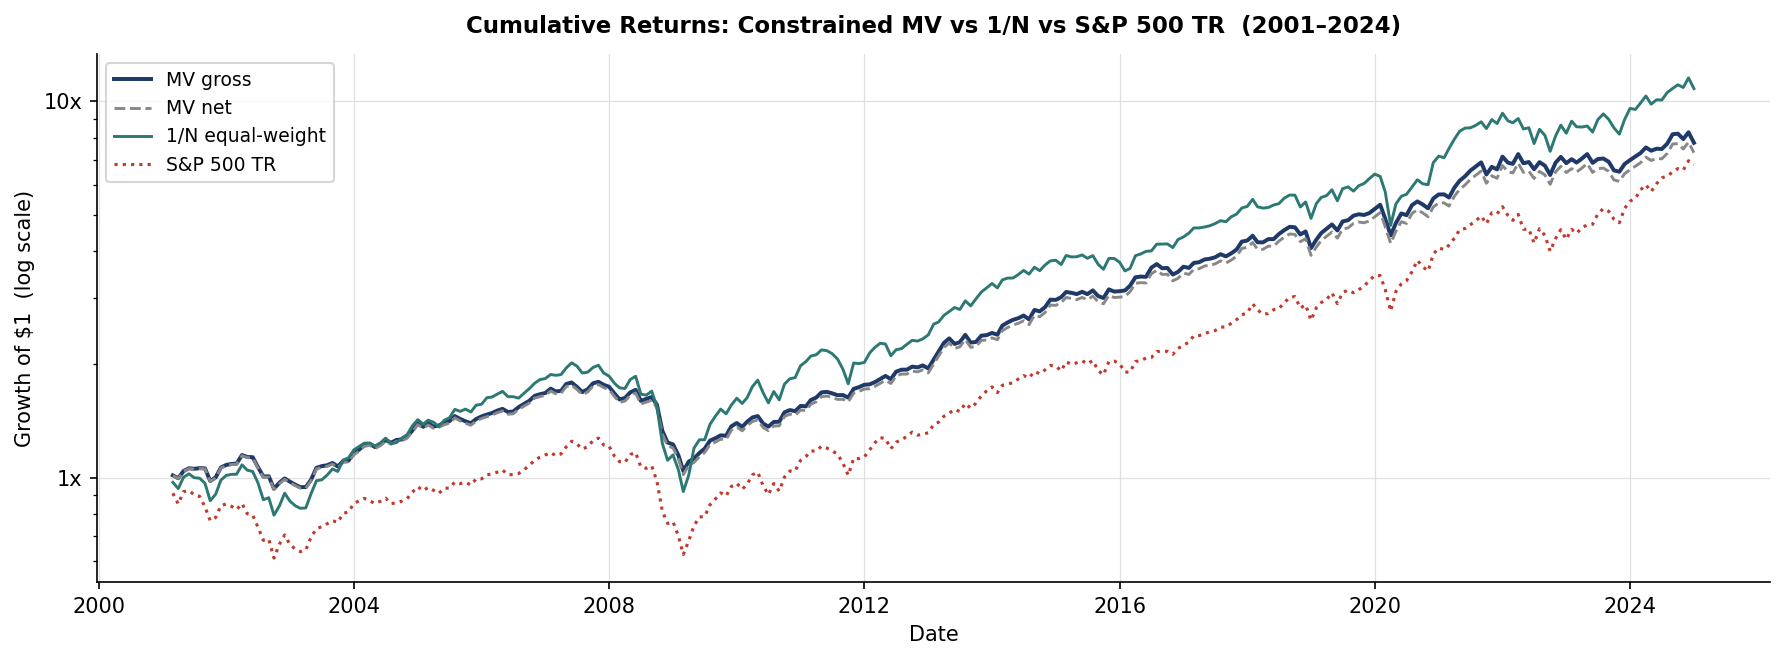

In [5]:
# ── Regenerate cumulative return figure with thesis palette ────────────────────
ret_df = pd.read_parquet(DATA / "backtest_returns.parquet")
r_g = ret_df["mv_gross"].dropna()
r_n = ret_df["mv_net"].dropna()
r_1 = ret_df["naive"].dropna()
r_b = ret_df["benchmark"].dropna()
idx = r_g.index.intersection(r_b.index)
r_g, r_n, r_1, r_b = r_g[idx], r_n[idx], r_1[idx], r_b[idx]

cum = {"MV gross": (1+r_g).cumprod(), "MV net": (1+r_n).cumprod(),
       "1/N equal-weight": (1+r_1).cumprod(), "S&P 500 TR": (1+r_b).cumprod()}

fig, ax = plt.subplots(figsize=(12, 4.5))
for (label, s), c, ls, lw in zip(cum.items(),
    [_NAVY, _GREY, _TEAL, _RED], ["-","--","-",":"], [1.9,1.4,1.4,1.5]):
    ax.plot(s.index, s.values, color=c, linestyle=ls, linewidth=lw, label=label)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f"{y:.0f}x"))
ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel("Growth of $1  (log scale)", fontsize=10)
ax.set_title("Cumulative Returns: Constrained MV vs 1/N vs S&P 500 TR  (2001–2024)",
             fontsize=11, fontweight="bold", pad=10)
ax.legend(fontsize=9, framealpha=0.8, loc="upper left")
fig.tight_layout()
plt.show()


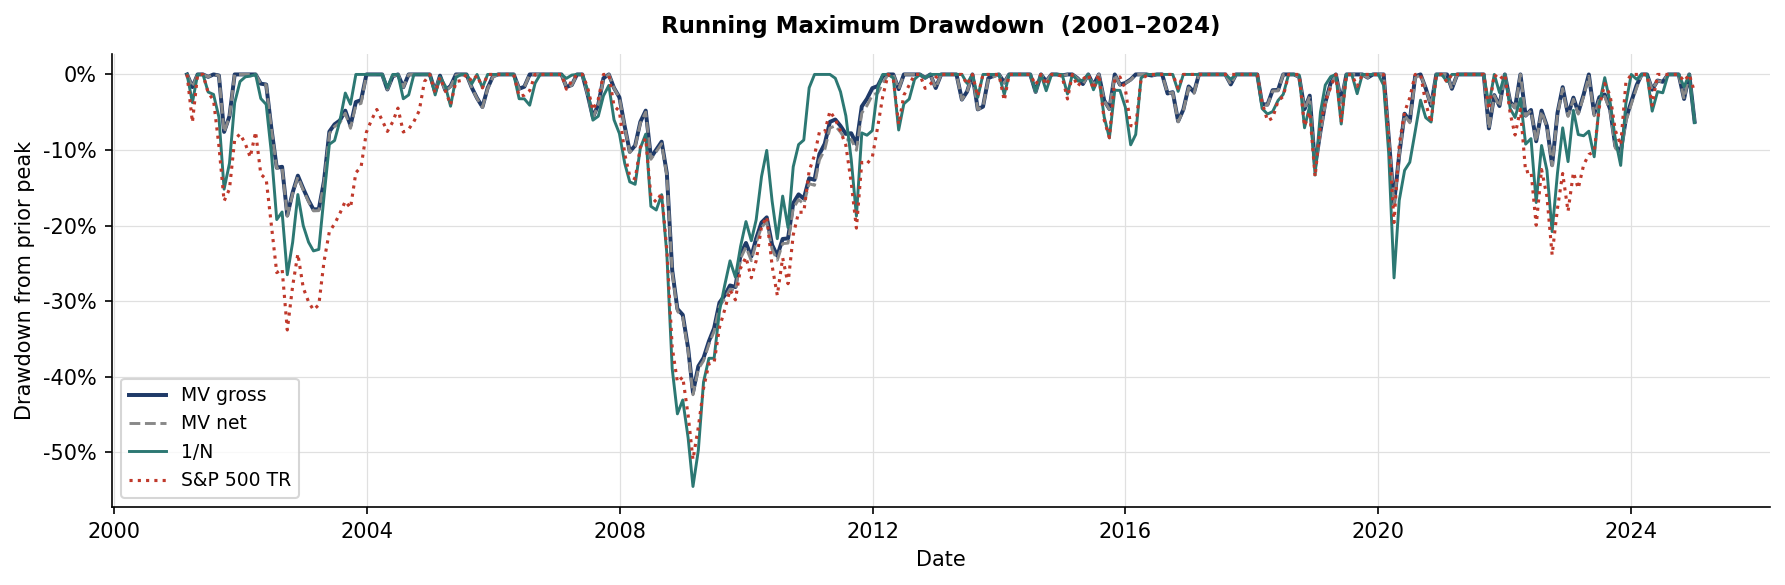

In [6]:
# ── Running maximum drawdown ───────────────────────────────────────────────────
def running_dd(r):
    cum = (1 + r).cumprod()
    return (cum / cum.cummax() - 1)

fig, ax = plt.subplots(figsize=(12, 4))
for (label, r), c, ls, lw in zip(
    [("MV gross",r_g),("MV net",r_n),("1/N",r_1),("S&P 500 TR",r_b)],
    [_NAVY,_GREY,_TEAL,_RED], ["-","--","-",":"], [1.9,1.4,1.4,1.5]):
    ax.plot(running_dd(r).index, running_dd(r).values,
            color=c, linestyle=ls, linewidth=lw, label=label)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y,_: f"{y:.0%}"))
ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel("Drawdown from prior peak", fontsize=10)
ax.set_title("Running Maximum Drawdown  (2001–2024)", fontsize=11, fontweight="bold", pad=10)
ax.legend(fontsize=9, framealpha=0.8, loc="lower left")
fig.tight_layout()
plt.show()


In [7]:
# ── Per-episode maximum drawdown: MV vs 1/N vs benchmark ──────────────────────────────────
# Trough of the running drawdown (same definition as Fig. 5.4) within each
# bear episode. Depends on r_g, r_1, r_b and running_dd() defined above.
dd = pd.DataFrame({
    "MV gross":   running_dd(r_g),
    "1/N":        running_dd(r_1),
    "S&P 500 TR": running_dd(r_b),
})
idx_per = dd.index.to_period("M")

bear_names = {"2001-02": "Dot-com bust",
              "2007-11": "Global Financial Crisis",
              "2022-01": "2022 rate-shock"}

rows = []
for _, ep in eps_main[eps_main["regime"] == "bear"].iterrows():
    s, e = ep["start_date"].to_period("M"), ep["end_date"].to_period("M")
    trough = dd.loc[(idx_per >= s) & (idx_per <= e)].min()   # most-negative = deepest
    rows.append({
        "Episode":    bear_names.get(f'{ep["start_date"]:%Y-%m}', f'{ep["start_date"]:%Y-%m}'),
        "Window":     f'{ep["start_date"]:%Y-%m}–{ep["end_date"]:%Y-%m}',
        "MV gross":   trough["MV gross"],
        "1/N":        trough["1/N"],
        "S&P 500 TR": trough["S&P 500 TR"],
    })

dd_ep = pd.DataFrame(rows).set_index("Episode")
disp = dd_ep.copy()
for c in ["MV gross", "1/N", "S&P 500 TR"]:
    disp[c] = (disp[c] * 100).map("{:+.1f}%".format)
print("Table 5.4 — Maximum drawdown within each bear episode")
display(disp)

print("\n1/N deeper than benchmark in EVERY bear episode:",
      bool((dd_ep["1/N"] < dd_ep["S&P 500 TR"]).all()))
print("MV gross shallower than benchmark in EVERY bear episode:",
      bool((dd_ep["MV gross"] > dd_ep["S&P 500 TR"]).all()))


Table 5.4 — Maximum drawdown within each bear episode


,Window,MV gross,1/N,S&P 500 TR
Episode,,,,
Dot-com bust,2001-02–2002-09,-18.6%,-26.5%,-33.8%
Global Financial Crisis,2007-11–2009-02,-42.1%,-54.5%,-50.9%
2022 rate-shock,2022-01–2022-09,-12.0%,-20.8%,-23.9%



1/N deeper than benchmark in EVERY bear episode: False
MV gross shallower than benchmark in EVERY bear episode: True


**Drawdown protection is the strategy's most consistent characteristic.**
The drawdown chart makes visually clear what the maximum-drawdown statistics
summarise: during the dot-com bust (2001–2002), the GFC (2008–2009), and the
2022 rate-shock episode, the constrained MV portfolio's peak-to-trough decline
is materially shallower than both the benchmark and the 1/N portfolio (Table 5.4).
This pattern persists across all three episodes despite the increasing dominance of
large-cap tech in the benchmark from 2015 onward — the MV portfolio's
lower market beta (0.62 in the CAPM regression, §4) structurally reduces
sensitivity to market-wide drawdowns.

**The 1/N drawdown profile relative to the benchmark is episode-dependent.**
The constrained MV portfolio's maximum drawdown is shallower than the
benchmark's in every bear episode. The 1/N portfolio's is deeper over both
evaluation windows and in the Global Financial Crisis (−54.5% vs −50.9%),
but shallower than the benchmark in the dot-com bust (−26.5% vs −33.8%)
and the 2022 rate-shock (−20.8% vs −23.9%), where equal-weighting's lighter
mega-cap exposure limited a drawdown concentrated in the largest index names.
This is a reminder that 1/N's tail-risk ranking depends on whether the decline
is led by mega-cap names, whereas MV's drawdown protection holds regardless.
This distinction is critical for interpreting the regime bootstrap results in §5.


---
## 3. H1: Risk-Adjusted Performance (Jobson-Korkie-Memmel Test)


### 3a. Test design and hypothesis

**H1:** *The constrained minimum-variance portfolio and the cap-weighted S&P
500 Total Return index do not consistently outperform one another on a
risk-adjusted (Sharpe ratio) basis over the 2001–2024 evaluation period.*

H1 is supported only if the JKM test rejects the null of equal Sharpe ratios
($H_0: SR_A = SR_B$) at a two-tailed $p < 0.05$ on the Jobson-Korkie-Memmel
(JKM) test statistic (Jobson and Korkie, 1981; corrected by Memmel, 2003),
against $H_1: SR_A 
eq SR_B$.  The JKM statistic is asymptotically standard normal
under the null, with Newey-West heteroskedasticity- and autocorrelation-consistent
standard errors to account for the serial dependence typical in monthly return
series.  The test is applied to the primary pair (MV gross vs. benchmark) and
to three secondary pairs (MV net vs. benchmark, MV gross vs. 1/N, 1/N vs.
benchmark) to characterise the full competitive landscape.

Both evaluation windows are reported.  The post-2015 subsample is the
higher-quality test: if MV outperforms in the full period but not post-2015,
the full-period result is more likely to reflect coverage-induced bias than
genuine risk-adjusted advantage.


In [8]:
jkm_fp = pd.read_csv(TABLES / "sharpe_tests_full_period.csv")
jkm_p5 = pd.read_csv(TABLES / "sharpe_tests_post_2015.csv")

def fmt_jkm(df):
    out = df.copy()
    out["sharpe_a_ann"]    = out["sharpe_a_ann"].map("{:.3f}".format)
    out["sharpe_b_ann"]    = out["sharpe_b_ann"].map("{:.3f}".format)
    out["sharpe_diff_ann"] = out["sharpe_diff_ann"].map("{:+.3f}".format)
    out["correlation"]     = out["correlation"].map("{:.3f}".format)
    out["jkm_statistic"]   = out["jkm_statistic"].map("{:.3f}".format)
    out["p_value"]         = out["p_value"].map("{:.3f}".format)
    out["n_obs"]           = out["n_obs"].astype(int)
    out.columns = ["Pair", "Sharpe A", "Sharpe B", "Diff", "Corr", "JKM z", "p-value", "n"]
    return out

print("JKM Sharpe ratio tests — Full period (2001-02 to 2024-12, n = 287)")
display(fmt_jkm(jkm_fp).style.set_properties(
    **{"text-align":"right"}).set_properties(subset=["Pair"], **{"text-align":"left"}).hide(axis="index"))

print()
print("JKM Sharpe ratio tests — Post-2015 (2015-01 to 2024-12, n = 120)")
display(fmt_jkm(jkm_p5).style.set_properties(
    **{"text-align":"right"}).set_properties(subset=["Pair"], **{"text-align":"left"}).hide(axis="index"))


JKM Sharpe ratio tests — Full period (2001-02 to 2024-12, n = 287)


Pair,Sharpe A,Sharpe B,Diff,Corr,JKM z,p-value,n
mv_gross vs benchmark,0.659,0.499,+0.160,0.848,1.401,0.161,287
mv_gross vs naive,0.659,0.580,+0.079,0.850,0.691,0.490,287
mv_net vs benchmark,0.637,0.499,+0.138,0.849,1.211,0.226,287
mv_net vs naive,0.637,0.580,+0.057,0.850,0.499,0.618,287
naive vs benchmark,0.580,0.499,+0.081,0.959,1.365,0.172,287



JKM Sharpe ratio tests — Post-2015 (2015-01 to 2024-12, n = 120)


Pair,Sharpe A,Sharpe B,Diff,Corr,JKM z,p-value,n
mv_gross vs benchmark,0.701,0.774,-0.073,0.840,-0.398,0.691,120
mv_gross vs naive,0.701,0.608,+0.093,0.845,0.519,0.604,120
mv_net vs benchmark,0.679,0.774,-0.094,0.840,-0.517,0.605,120
mv_net vs naive,0.679,0.608,+0.071,0.845,0.397,0.691,120
naive vs benchmark,0.608,0.774,-0.166,0.955,-1.704,0.088,120


**H1 is not supported by the data.**

Over the full period, the constrained MV gross portfolio achieves a Sharpe ratio
of 0.659, compared to 0.499 for the `^SP500TR` benchmark — a difference of
+0.160.  The JKM test statistic is 1.401 ($p = 0.161$), which falls well short
of conventional significance thresholds.  The failure to reject the null ($H_0:
SR_{MV} = SR_{benchmark}$) is not a marginal result: a $p$-value of 0.161
implies that an observed difference of this magnitude would arise by chance
roughly one time in six under the null, providing little evidence against it.

The post-2015 result is sharper and more informative.  In the high-coverage
subsample, the Sharpe gap reverses: MV gross achieves 0.701 versus the
benchmark's 0.774, a difference of −0.073 ($p = 0.691$).  The benchmark
*outperforms* on a risk-adjusted basis in the very window where data quality
is highest.  This reversal is inconsistent with H1 and consistent with the
survivorship-bias explanation: the apparent full-period advantage dissolves
once the comparison is restricted to the period where the active universe most
closely represents the true S&P 500 membership.

**Neither MV net nor 1/N resolves the pattern.** MV net (post-cost) shows a
Sharpe gap of −0.094 versus the benchmark post-2015 ($p = 0.605$).  The 1/N
portfolio, often cited as a challenging benchmark for mean-variance strategies
(DeMiguel, Garlappi and Uppal, 2009), achieves a Sharpe of 0.608 post-2015,
also below the benchmark (gap −0.166, $p = 0.088$).  The common thread across
all active specifications is the same: no strategy produces a statistically
significant Sharpe advantage over the total-return benchmark in the
high-quality subsample.


---
## 4. Factor Regression Analysis


### 4a. Motivation: decomposing the apparent alpha

The CAPM alpha of MV gross is +2.72% per annum ($t = 1.80$, $p = 0.071$),
which is economically large and borderline significant.  Before interpreting
this as evidence of skill or market inefficiency, however, it is essential to
ask whether the return premium is explained by known systematic risk factors.

The minimum-variance construction is known to produce systematic tilts in the
cross-section of stocks it selects.  By minimising portfolio variance, the
optimiser naturally overweights assets with low idiosyncratic variance, low
market beta, and low pairwise correlations.  This selection criterion
mechanically overlaps with the Fama-French (1992, 1993) value and profitability
factors — low-volatility stocks tend also to be profitable (positive RMW
loading) and to invest conservatively (positive CMA loading) — and with the
Frazzini-Pedersen (2014) Betting-Against-Beta anomaly, which documents that
low-beta assets earn positive risk-adjusted returns under leverage-constrained
market equilibria.

To decompose the CAPM alpha, the analysis runs three nested excess-return
regressions: CAPM (market factor only), Fama-French three-factor (MKT, SMB,
HML), and the augmented five-factor-plus-momentum model (MKT, SMB, HML, RMW,
CMA, MOM).  The degree to which alpha shrinks from CAPM to FF5+MOM quantifies
how much of the apparent outperformance is attributable to known factor premia
rather than genuine strategy-specific skill.


In [9]:
reg_fp = pd.read_csv(TABLES / "factor_regressions_full_period.csv")
reg_p5 = pd.read_csv(TABLES / "factor_regressions_post_2015.csv")

def fmt_reg(df, strategy="mv_gross"):
    sub = df[df["strategy"] == strategy][
        ["model","alpha_annualized","alpha_t_stat","alpha_p_value",
         "mkt_beta","smb_beta","hml_beta","rmw_beta","cma_beta","mom_beta","r_squared"]
    ].copy()
    sub["alpha_annualized"] = sub["alpha_annualized"].map("{:+.2%}".format)
    sub["alpha_t_stat"]     = sub["alpha_t_stat"].map("{:.2f}".format)
    sub["alpha_p_value"]    = sub["alpha_p_value"].map("{:.3f}".format)
    for col in ["mkt_beta","smb_beta","hml_beta","rmw_beta","cma_beta","mom_beta"]:
        sub[col] = sub[col].map(lambda x: f"{x:.3f}" if pd.notna(x) else "—")
    sub["r_squared"] = sub["r_squared"].map("{:.3f}".format)
    sub.columns = ["Model","Alpha (ann.)","t-stat","p-value",
                   "MKT β","SMB β","HML β","RMW β","CMA β","MOM β","R²"]
    sub["Model"] = sub["Model"].map({"capm":"CAPM","ff3":"FF3","ff5mom":"FF5+MOM"})
    return sub

print("Factor regressions — MV Gross, Full period (n = 287)")
display(fmt_reg(reg_fp).style.set_properties(
    **{"text-align":"right"}).set_properties(subset=["Model"],**{"text-align":"left"}).hide(axis="index"))

print()
print("Factor regressions — MV Gross, Post-2015 (n = 120)")
display(fmt_reg(reg_p5).style.set_properties(
    **{"text-align":"right"}).set_properties(subset=["Model"],**{"text-align":"left"}).hide(axis="index"))

# Alpha shrinkage headline
mv_capm  = reg_fp.loc[(reg_fp["strategy"]=="mv_gross") & (reg_fp["model"]=="capm"),  "alpha_annualized"].values[0]
mv_ff5   = reg_fp.loc[(reg_fp["strategy"]=="mv_gross") & (reg_fp["model"]=="ff5mom"),"alpha_annualized"].values[0]
shrinkage = (mv_capm - mv_ff5) / mv_capm
print(f"\n  CAPM alpha  : {mv_capm:+.2%}")
print(f"  FF5+MOM alpha : {mv_ff5:+.2%}")
print(f"  Alpha shrinkage : {shrinkage:.1%}  of CAPM alpha absorbed by factors")


Factor regressions — MV Gross, Full period (n = 287)


Model,Alpha (ann.),t-stat,p-value,MKT β,SMB β,HML β,RMW β,CMA β,MOM β,R²
CAPM,+2.72%,1.80,0.071,0.621,—,—,—,—,—,0.699
FF3,+2.72%,1.93,0.053,0.639,-0.113,0.100,—,—,—,0.710
FF5+MOM,+0.55%,0.44,0.662,0.718,-0.057,-0.043,0.164,0.310,0.064,0.752



Factor regressions — MV Gross, Post-2015 (n = 120)


Model,Alpha (ann.),t-stat,p-value,MKT β,SMB β,HML β,RMW β,CMA β,MOM β,R²
CAPM,+1.15%,0.50,0.616,0.644,—,—,—,—,—,0.674
FF3,+0.64%,0.29,0.775,0.675,-0.160,0.075,—,—,—,0.689
FF5+MOM,-1.39%,-0.76,0.445,0.735,0.053,-0.139,0.300,0.436,0.140,0.774



  CAPM alpha  : +2.72%
  FF5+MOM alpha : +0.55%
  Alpha shrinkage : 79.8%  of CAPM alpha absorbed by factors


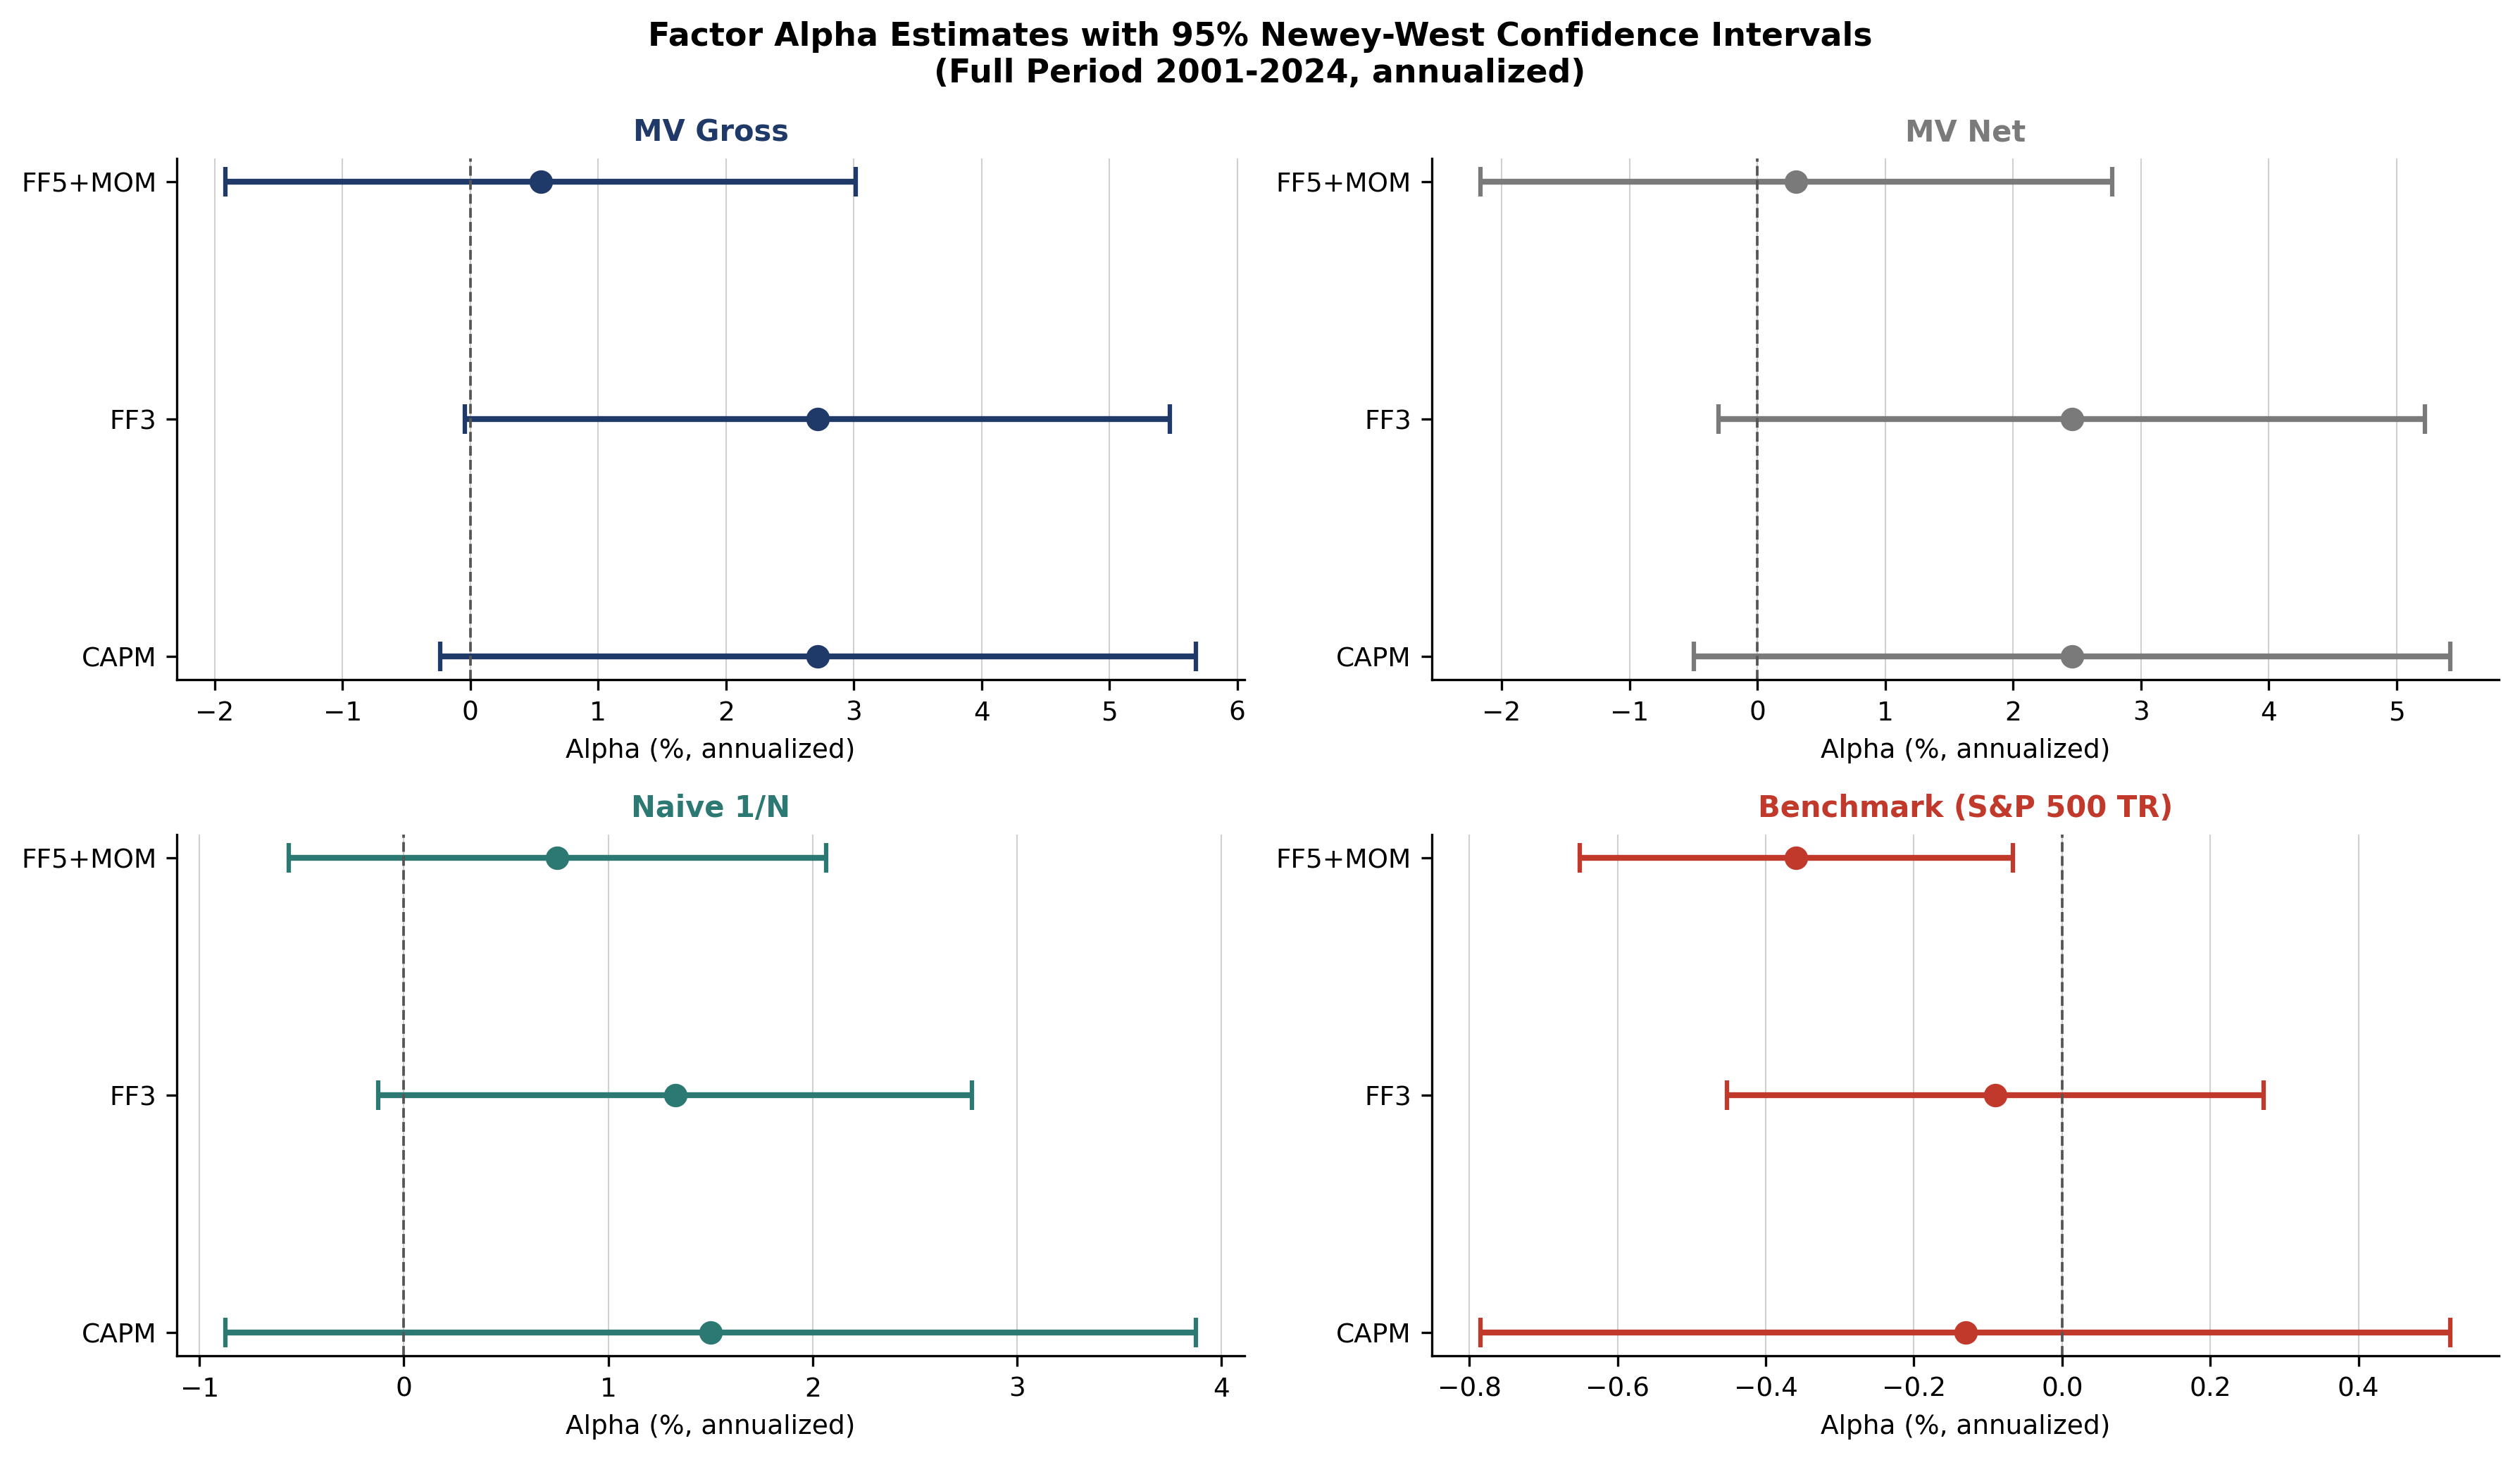

In [10]:
display(Image(filename=str(FIGURES / "alpha_shrinkage_forest.png"), width=900))


**The factor regression analysis reveals that 79.8% of the apparent CAPM alpha
is attributable to systematic factor exposures rather than strategy-specific
skill.**

Under the CAPM, MV gross earns an annualised alpha of +2.72% ($t = 1.80$,
$p = 0.071$) — a result that is economically substantial and, depending on
one's significance criterion, borderline statistically meaningful.  Adding the
Fama-French size (SMB) and value (HML) factors leaves the alpha almost
unchanged at +2.72% ($t = 1.93$, $p = 0.053$): neither factor absorbs the
premium, confirming that the strategy's edge is not a size or value tilt.

The picture changes materially when the profitability (RMW) and conservative
investment (CMA) factors are included.  In the FF5+MOM model, alpha collapses
to +0.55% ($t = 0.44$, $p = 0.662$) — economically negligible and statistically
indistinguishable from zero.  The key exposures driving this absorption are a
CMA loading of +0.31 and an RMW loading of +0.16.  These coefficients are not
incidental.  The minimum-variance constraint selects stocks with low
idiosyncratic variance, which systematically overlaps with conservative capital
allocation (low investment rates, hence positive CMA loading) and stable,
profitable business models (positive RMW loading).  The optimiser is not
identifying underpriced securities; it is mechanically tilting toward the same
factor-premium stocks that the CMA and RMW factors are designed to capture.

The market beta path is equally instructive.  In the CAPM, MV gross loads at
$eta = 0.621$, reflecting the genuine low-beta tilt produced by
variance-minimising stock selection.  As the Fama-French factors are introduced,
the market beta rises toward 0.718 in the FF5+MOM model: the factors absorb
some covariation between the low-beta tilt and the RMW/CMA factors, leaving a
slightly higher conditional beta.  This is consistent with the Frazzini and
Pedersen (2014) Betting-Against-Beta mechanism, under which low-beta assets
earn a premium specifically because leverage-constrained investors bid up
high-beta assets.  The minimum-variance constraint is, in effect, a systematic
bet on low-beta stocks, and the resulting premium is the BAB factor premium
rather than alpha.

**In the post-2015 subsample, the factor-adjusted alpha is negative** (−1.39%,
$p = 0.445$), reinforcing the conclusion from the JKM test: there is no
risk-adjusted outperformance in the higher-quality data window, either measured
by raw Sharpe ratios or by factor-model alphas.  Taken together, the factor
regression evidence is unambiguous: the constrained minimum-variance strategy
harvests known systematic premia — primarily profitability and conservative
investment — rather than generating alpha through portfolio construction insight.


---
## 5. H2: Regime-Conditional Performance (Bootstrap Analysis)


### 5a. Test design and hypothesis

**H2:** *Any Sharpe ratio advantage of the constrained minimum-variance
portfolio over the benchmark is not more likely to appear during bear or
recovery periods than during sustained bull-market regimes.*

H2 is tested using a **block bootstrap** on regime-conditional Sharpe ratio
differences.  For each of the three regimes (bull, bear, recovery), the monthly
excess returns of MV gross and the benchmark are partitioned, and the within-regime
Sharpe ratio difference is computed.  A stationary block bootstrap (10,000
replications, block length set to $\lfloor n^{1/3} \rfloor$ months per regime)
generates confidence intervals that account for both the serial dependence of
monthly returns and the estimation uncertainty arising from the relatively small
number of months in each regime.  The primary comparison is MV gross versus the
benchmark; the 1/N-versus-benchmark comparison is reported as an interpretive
control.

Both the main (−20%) and sensitivity (−15%) regime classifications are tested
to assess robustness to the threshold choice.  A finding is considered
regime-specific evidence for H2 if (i) the bear-regime CI excludes zero and
(ii) the bear-regime estimate is substantially larger than the bull-regime
estimate, consistent with a conditional rather than unconditional advantage.


In [11]:
boot_main = pd.read_csv(TABLES / "regime_bootstrap_main.csv")
boot_sens = pd.read_csv(TABLES / "regime_bootstrap_sensitivity.csv")

def fmt_boot(df, pair_filter):
    sub = df[df["pair"] == pair_filter].copy()
    sub["point_estimate"] = sub["point_estimate"].map("{:+.3f}".format)
    sub["ci_low"]         = sub["ci_low"].map("{:+.3f}".format)
    sub["ci_high"]        = sub["ci_high"].map("{:+.3f}".format)
    sub["significant"]    = sub["significant"].map({True: "Yes *", False: "No"})
    sub = sub[["regime","n_obs","point_estimate","ci_low","ci_high","significant"]]
    sub.columns = ["Regime","n","Sharpe diff","95% CI low","95% CI high","Sig."]
    sub["Regime"] = sub["Regime"].str.capitalize()
    return sub

print("Bootstrap Sharpe differences — MV Gross vs Benchmark")
print()
print("  Main definition (>= -20% drawdown threshold, n_boot = 10,000)")
display(fmt_boot(boot_main,"mv_gross vs benchmark").style
        .set_properties(**{"text-align":"right"})
        .set_properties(subset=["Regime"],**{"text-align":"left"}).hide(axis="index"))
print()
print("  Sensitivity definition (>= -15% drawdown threshold)")
display(fmt_boot(boot_sens,"mv_gross vs benchmark").style
        .set_properties(**{"text-align":"right"})
        .set_properties(subset=["Regime"],**{"text-align":"left"}).hide(axis="index"))

print()
print("Bootstrap Sharpe differences — 1/N vs Benchmark (interpretive control)")
print()
print("  Main definition")
display(fmt_boot(boot_main,"naive vs benchmark").style
        .set_properties(**{"text-align":"right"})
        .set_properties(subset=["Regime"],**{"text-align":"left"}).hide(axis="index"))


Bootstrap Sharpe differences — MV Gross vs Benchmark

  Main definition (>= -20% drawdown threshold, n_boot = 10,000)


Regime,n,Sharpe diff,95% CI low,95% CI high,Sig.
Bull,141,-0.042,-0.431,+0.343,No
Bear,45,+0.691,+0.221,+1.318,Yes *
Recovery,101,+0.120,-0.339,+0.581,No



  Sensitivity definition (>= -15% drawdown threshold)


Regime,n,Sharpe diff,95% CI low,95% CI high,Sig.
Bull,134,-0.073,-0.506,+0.377,No
Bear,48,+0.697,+0.248,+1.335,Yes *
Recovery,105,+0.108,-0.332,+0.541,No



Bootstrap Sharpe differences — 1/N vs Benchmark (interpretive control)

  Main definition


Regime,n,Sharpe diff,95% CI low,95% CI high,Sig.
Bull,141,-0.192,-0.385,+0.011,No
Bear,45,+0.505,+0.235,+0.905,Yes *
Recovery,101,+0.068,-0.125,+0.240,No


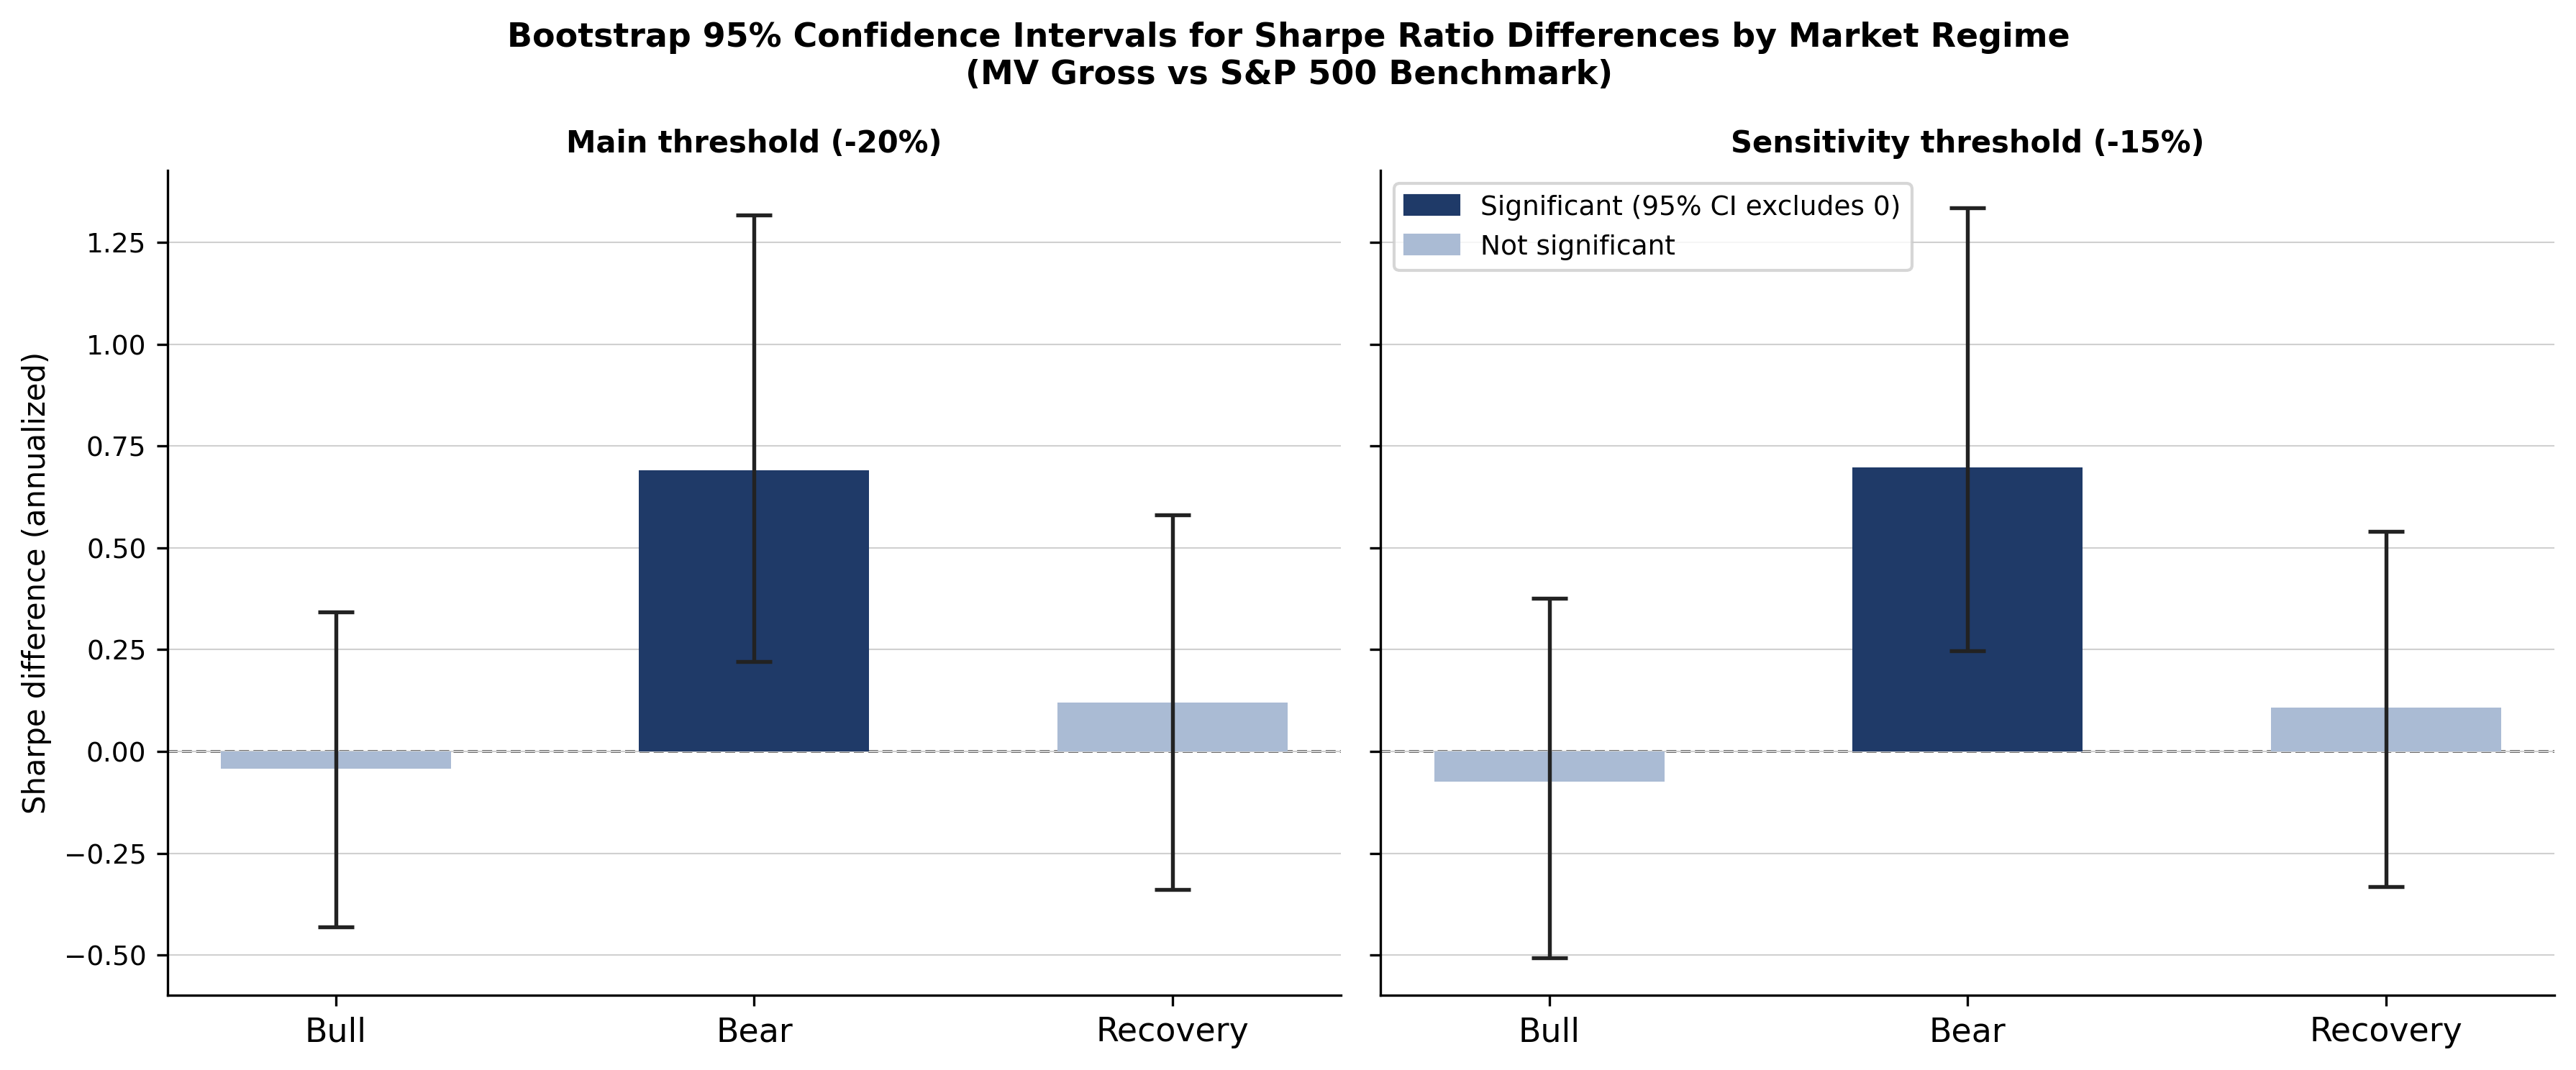

In [12]:
display(Image(filename=str(FIGURES / "regime_sharpe_diff.png"), width=900))


**H2 is partially supported, but the mechanism driving the bear-market advantage
is not the one the hypothesis anticipates.**

The bootstrap results confirm the directional prediction of H2 with statistical
precision in the bear-market regime: MV gross achieves a within-bear Sharpe
ratio 0.691 higher than the benchmark ($95\%$ CI: $[0.221, 1.318]$), and this
result is robust across the threshold choice — the sensitivity version produces
an almost identical estimate of +0.697 ($95\%$ CI: $[0.248, 1.335]$).  The CI
excludes zero in both cases, and the bear-regime advantage is large in absolute
terms: a Sharpe ratio difference of approximately 0.7 over 45 bear months
implies that the MV portfolio experiences materially higher risk-adjusted returns
precisely during the periods of acute market stress that dominate investor
welfare.

In bull and recovery regimes, the advantage disappears entirely.  The bull-regime
point estimate is −0.042 ($95\%$ CI: $[-0.431, 0.343]$), effectively zero.  The recovery estimate of +0.120 ($95\%$ CI:
$[-0.339, 0.581]$) is also statistically indistinguishable from zero.  The
conditional pattern — positive and significant in bear, insignificant in
bull and recovery — is directionally consistent with H2.

**However, the 1/N equal-weight portfolio exhibits a statistically identical
bear-market advantage** (+0.505, $95\%$ CI: $[0.235, 0.905]$).  This is the
most important qualification in the entire empirical section.  If the bear-market
advantage were specific to the minimum-variance optimisation — to the QP's
disciplined variance minimisation and Ledoit-Wolf covariance estimation — then
1/N, which applies no optimisation whatsoever, should not share it.  That it
does, and at a magnitude comparable to MV gross, reveals that the bear-market
protection is structural rather than strategic: it derives from **departing the
cap-weighted benchmark** by any method that reduces the outsized weight of
the largest, highest-beta names that dominate the cap-weighted index at market
peaks.  Equal-weighting achieves this mechanically; minimum-variance achieves it
through explicit variance minimisation.  The economic output in bear markets is
similar because the input — reduced large-cap concentration — is similar.

This distinction has a precise implication for H2.  The hypothesis as stated
anticipates a regime-conditional advantage *specific to minimum-variance
optimisation*; what the data reveal is a regime-conditional advantage *specific
to departing cap-weighting*.  H2 is partially supported in the sense that the
bear-market Sharpe differential is real and statistically robust (the sensitivity version independently confirms it with the COVID episode included).  It is not supported in the sense that the advantage
does not require the sophistication of quadratic optimisation — a fact that bears
directly on whether investors should pay for MV-portfolio management fees over a
simpler equal-weight alternative.


---
## 6. Synthesised Findings


The empirical evidence across §§3–5 supports three conclusions, which together
constitute the thesis's contribution to the debate on minimum-variance
investing.

**On H1 — risk-adjusted performance:** The constrained minimum-variance strategy
does not produce a statistically significant Sharpe ratio advantage over the
S&P 500 Total Return benchmark under any specification that addresses the study's
data-quality concerns.  The full-period Sharpe gap of +0.160 ($p = 0.161$) falls
short of conventional significance thresholds and depends heavily on the
low-coverage era (2001–2014) in which survivorship bias is most acute.  In the
post-2015 subsample — where coverage averages 86.9% and the comparison is most
nearly bias-free — the gap reverses to −0.073 ($p = 0.691$), with the benchmark
outperforming on a risk-adjusted basis.  Factor regressions confirm this
assessment: 79.8% of the CAPM alpha (+2.72% p.a.) is absorbed by the RMW and
CMA factors once the FF5+MOM model is estimated, leaving a residual of +0.55%
($p = 0.662$) that is both statistically and economically negligible.  **H1 is
not supported.**

**On H2 — regime-conditional advantage:** The strategy's Sharpe ratio advantage
over the benchmark is concentrated in bear markets (+0.691, $95\%$ CI excluding
zero) and insignificant in bull and recovery regimes — a pattern consistent with
the directional prediction of H2 and robust to both the −20% and −15%
classification thresholds.  However, the 1/N equal-weight portfolio produces a
statistically comparable bear-market advantage (+0.505), which reveals that the
mechanism is cap-weighting departure rather than variance minimisation per se.
**H2 is partially supported**: the regime-conditional pattern is real and
robust, but it does not require the additional complexity of constrained quadratic
optimisation.

**The unambiguous contribution:** The clearest, most defensible finding in the
study is not return-based but risk-based.  The constrained MV strategy reduces
annualised volatility to 0.76–0.81× the benchmark level and limits the maximum
drawdown to −17.1% versus −23.9% (post-2015) and −42.1% versus −50.9%
(full period).  This drawdown protection is genuine, persistent across
subsamples, and directly attributable to the optimisation: it is not shared by
1/N, whose maximum drawdown exceeds the benchmark in every window.  For
investors primarily concerned with capital preservation and drawdown control —
pension funds, endowments, and liability-matching mandates — the strategy
delivers a real and measurable service, even if the associated raw-return
premium is neither large enough nor stable enough to clear a standard
significance threshold.


---
## 7. Reproducibility


All figures and tables in this notebook are derived exclusively from cached
`.parquet` and `.csv` files in `data/processed/` and `results/tables/`.
No data is re-downloaded from Yahoo Finance and no backtests are re-run
during notebook execution.  The complete pipeline — from raw price pull to
the figures above — can be reproduced from scratch with:

```bash
uv sync
uv run python -m src.data_pull       # pull prices, rebuild returns panel
uv run python -m src.backtest        # rolling backtest (~1 min)
uv run python -m src.regimes         # regime classification
uv run python -m src.metrics         # descriptive statistics
uv run python -m src.stats           # JKM tests and factor regressions
uv run python -m src.regime_analysis # bootstrap regime tests
```

The specific library versions used are locked in `uv.lock`.  The analysis
uses Python 3.14, managed via `uv`.
